# Exercise 4: NumPy Array Operations

In [56]:
import numpy as np

Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

In [57]:
# Create a 5x5 matrix of ones
matrix = np.ones((5, 5))

# Set interior elements to 0
matrix[1:-1, 1:-1] = 0

print("Task 1 Result:")
print(matrix)

Task 1 Result:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


Task 2: Normalize a random array

In [58]:
np.random.seed(42)
random_data = np.random.randn(100, 3)
# Compute mean and std per column
mean = random_data.mean(axis=0)
std = random_data.std(axis=0)

# Normalize
normalized_data = (random_data - mean) / std

print("Task 2: Column means after normalization:")
print(normalized_data.mean(axis=0))

print("Task 2: Column std after normalization:")
print(normalized_data.std(axis=0))

Task 2: Column means after normalization:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Task 2: Column std after normalization:
[1. 1. 1.]


Task 3: Implement linear regression solution using normal equation

In [59]:
# Data
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Add bias term (important for full linear regression model)
# If your assignment expects bias, uncomment below:
# X = np.c_[np.ones(X.shape[0]), X]

# Normal equation
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ y

theta_hat = XtX_inv @ Xty

print("Estimated theta:", theta_hat)
print("True theta:", true_theta)
print("Difference:", theta_hat - true_theta)

Estimated theta: [ 2.51723721 -1.19783796  3.72399266]
True theta: [ 2.5 -1.2  3.7]
Difference: [0.01723721 0.00216204 0.02399266]


# Exercise 5: Pandas Data Analysis (30 points)

In [60]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce NaNs
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

TASK 1: Data Cleaning & Exploration

In [61]:
# TODO: Display basic information about the datase
print("Data Info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

First 5 rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14

In [62]:
# TODO: Identify and count missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64


In [63]:
# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

In [64]:
# TODO: Fill missing hours_studied with the median for the student's year

df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

TASK 2: Analysis

In [65]:
# TODO: Calculate and display the average exam_score by major
print("\nAverage exam score by major:")
print(df.groupby('major')['exam_score'].mean())



Average exam score by major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64


In [66]:
# TODO: Find the major with the highest average exam_score
avg_by_major = df.groupby('major')['exam_score'].mean()
print("\nTop major:")
print(avg_by_major.idxmax(), "with score", avg_by_major.max())


Top major:
CS with score 76.42518387979709


In [67]:
# TODO: Calculate the correlation between hours_studied and exam_score
corr = df['hours_studied'].corr(df['exam_score'])
print("\nCorrelation between hours studied and exam score:", corr)


Correlation between hours studied and exam score: -0.055981383472924404


In [68]:
# TODO: Create a new column 'performance' with categories:  'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

def performance_category(score):
    if score >= 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(performance_category)

print("\nPerformance distribution:")
print(df['performance'].value_counts())


Performance distribution:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


TASK 3: Advanced Analysis

In [69]:
# TODO: For each major and year combination, calculate: Number of students,Average exam score, Average hours studied
summary = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

print("\nMajor-Year Summary:")
print(summary)


Major-Year Summary:
              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13       76.570059          12.677806
        2               12       74.899613          13.426372
        3               14       80.178476          14.486815
        4               15       70.697689          14.253944
CS      1               12       77.098194          13.039480
        2                7       76.155936          13.995784
        3                9       72.347626          15.039892
        4               18       78.119997          16.275541
Math    1               11       74.053167          19.001215
        2                9       81.226714          12.345468
        3               10       72.017537          15.175871
        4               16       73.103066          17.419175
Physics 1               13       77.828686          13.489911
        2               12       73.277734       

In [70]:
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)

top_students = df.sort_values('exam_score', ascending=False).head(5)

print("\nTop 5 students:")
print(top_students[['student_id', 'major', 'exam_score']])

top_students = df.nlargest(5, 'exam_score')


Top 5 students:
     student_id    major  exam_score
57         1057       CS  100.000000
27         1027     Math  100.000000
68         1068  Biology   98.146586
82         1082       CS   96.439441
132        1132       CS   96.330334


In [71]:
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table (Avg Exam Score):")
print(pivot)


Pivot Table (Avg Exam Score):
year             1          2          3          4
major                                              
Biology  76.570059  74.899613  80.178476  70.697689
CS       77.098194  76.155936  72.347626  78.119997
Math     74.053167  81.226714  72.017537  73.103066
Physics  77.828686  73.277734  73.134319  78.130194


#Exercise 6: Data Visualization

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

Task 1: Distribution Visualization

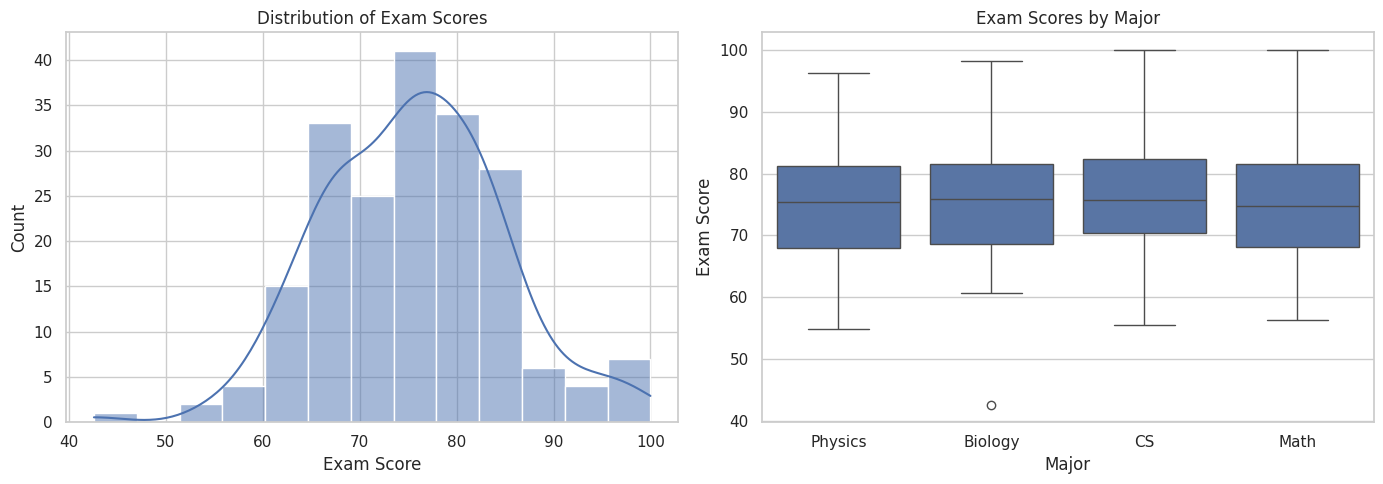

In [73]:
# TODO: Create a figure with 2 subplots side by side  Left: Histogram of exam scores with KDE overlay,   Right: Box plot of exam scores by major
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Left: Histogram with  KDE
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")

# Right: Boxplot by major

sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()



Task 2: Relationship Visualization (8 points)


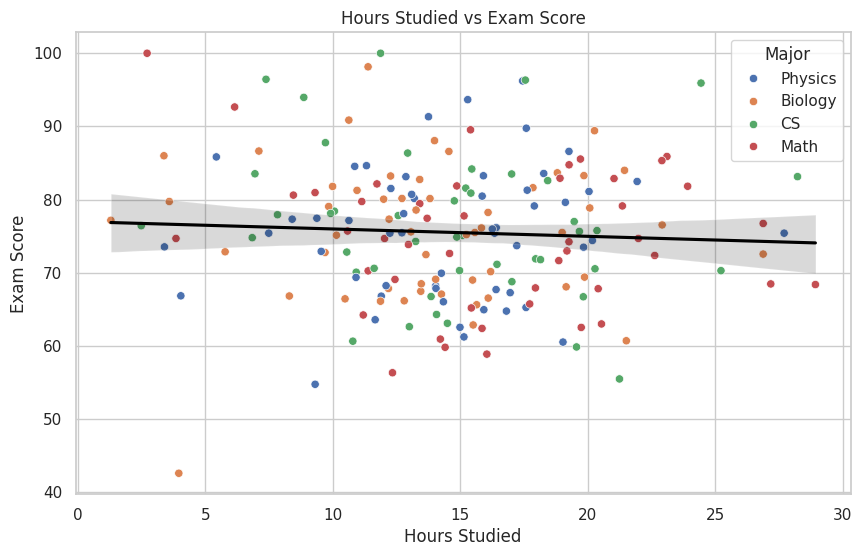

In [74]:
# TODO: Create a scatter plot of hours_studied vs exam_score

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)
# TODO: Add a regression line
# Regression line (overall, not per major)
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)

# TODO: Include appropriate legends, titles, and axis labels

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()


Task 3: Advanced Dashboard


/tmp/ipykernel_2712/859831980.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=30)


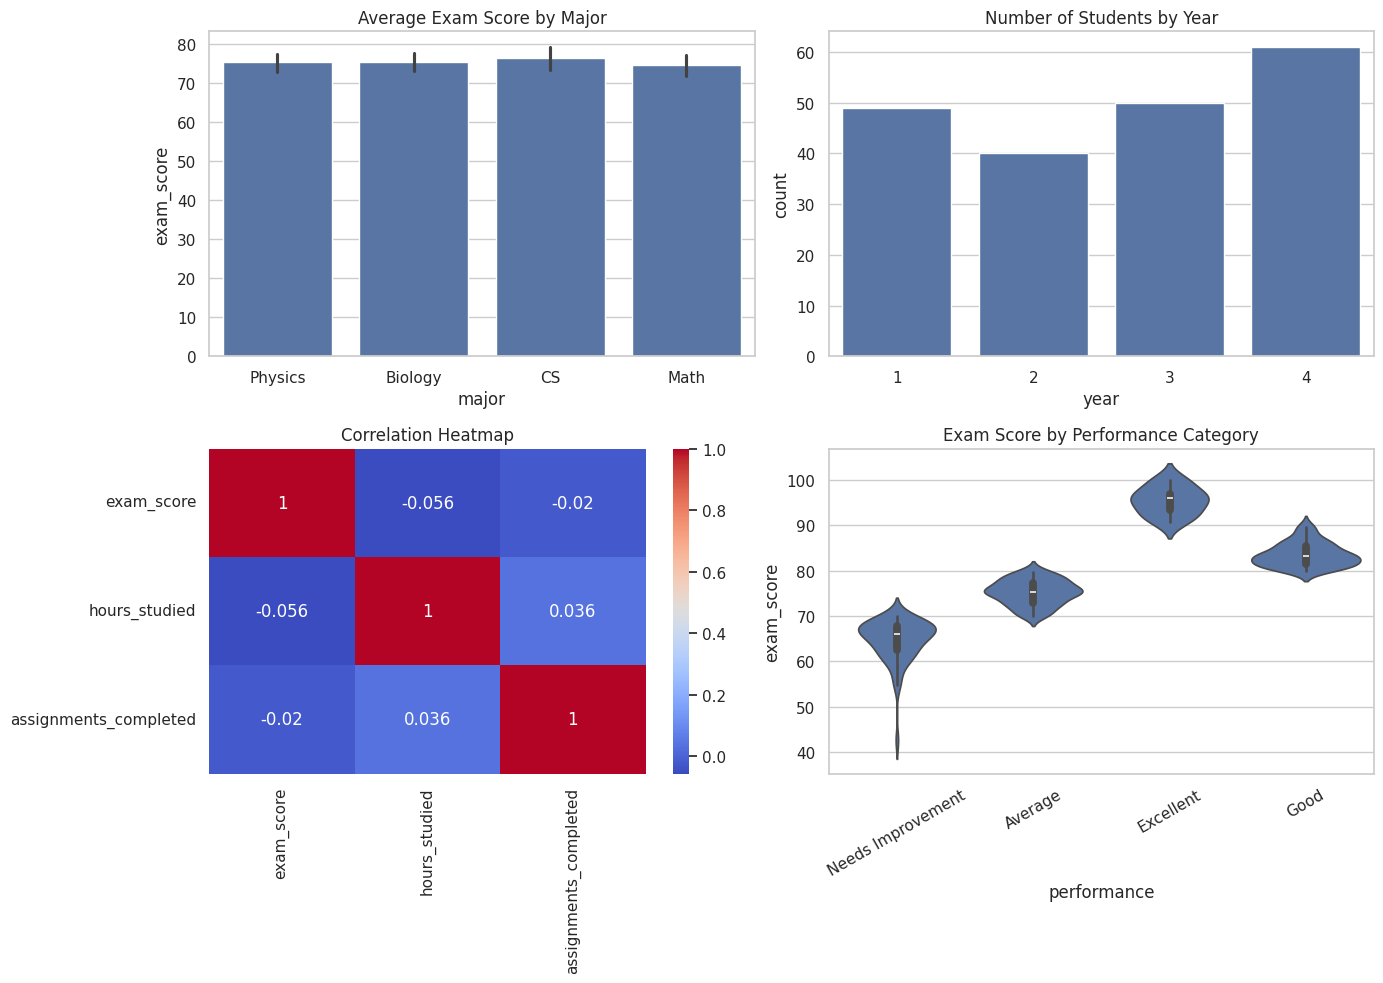

In [75]:
# TODO: Create a 2x2 subplot figure containing:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Avg exam score by major

sns.barplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Exam Score by Major")


# 2. Count plot: Students by year
sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)
axes[0, 1].set_title("Number of Students by Year")

# 3. Heatmap: Correlation matrix

corr = df[['exam_score', 'hours_studied', 'assignments_completed']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Correlation Heatmap")


# 4. Violin plot: performance categories

sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Exam Score by Performance Category")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

# Exercise 7: Integration Challenge


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [77]:
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

In [78]:

# TODO: Calculate customer lifetime value (CLV)

max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)

customers['clv'] = (
    customers['purchase_frequency'] *
    customers['avg_purchase_value'] *
    (1 + customers['churn_risk'])
)

print(customers.head())

   age        income  purchase_frequency  avg_purchase_value  churn_risk  \
0   56  92443.123940                   7           94.527456    0.416667   
1   69  70649.305211                   2          100.932279    0.833333   
2   46  19612.600681                   3           79.699876    0.750000   
3   32  40315.318543                   2          130.137787    0.833333   
4   60  75338.222984                   8          102.904845    0.333333   

           clv  
0   937.397271  
1   370.085023  
2   418.424348  
3   477.171887  
4  1097.651683  


In [79]:
# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70

bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)

print(customers[['age', 'age_group']].head())

   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70


In [80]:
# TODO: For each age group, calculate: Number of customers, Average income,  Average CLV, Total CLV


group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('clv', 'mean'),
    total_clv=('clv', 'sum')
)

print(group_stats)

           num_customers    avg_income     avg_clv      total_clv
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683


/tmp/ipykernel_2712/1920039505.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = customers.groupby('age_group').agg(


In [81]:
# TODO: Identify top 10% of customers by CLV

threshold = customers['clv'].quantile(0.90)

top_customers = customers[customers['clv'] >= threshold]

print("Top 10% Customers:")
print(top_customers[['age', 'income', 'clv']].head())

Top 10% Customers:
    age        income          clv
6    38  58876.388563  1287.201143
9    40  48809.492879  1286.000108
19   41  21282.756976  1276.279663
24   38  53981.193911  1283.421714
57   64  45956.146951  1343.416638


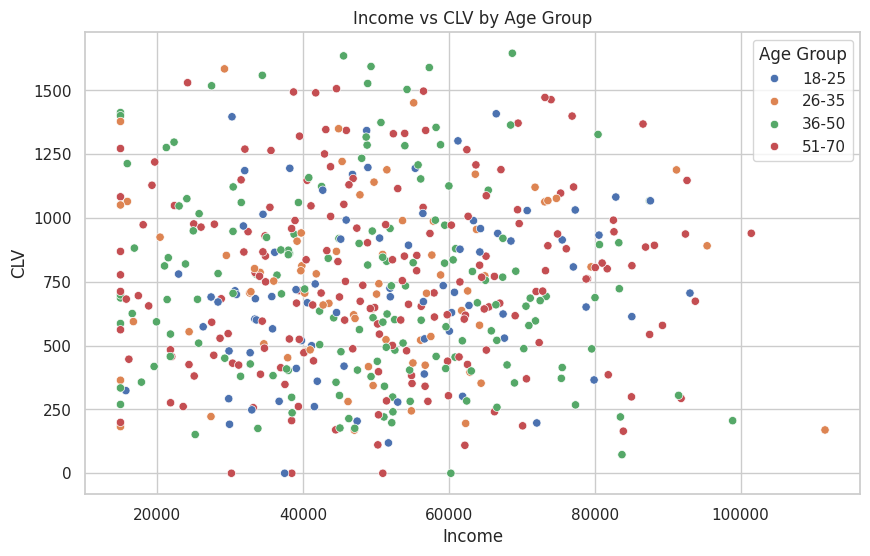

In [82]:
# 1. Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers,
    x='income',
    y='clv',
    hue='age_group'
)

plt.title("Income vs CLV by Age Group")
plt.xlabel("Income")
plt.ylabel("CLV")
plt.legend(title="Age Group")
plt.show()


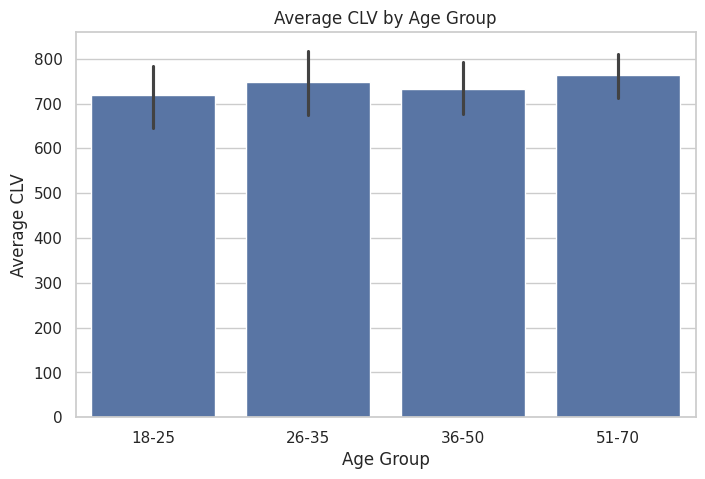

In [83]:
# 2. Bar chart of average CLV by age group

plt.figure(figsize=(8, 5))

sns.barplot(
    data=customers,
    x='age_group',
    y='clv'
)

plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.show()


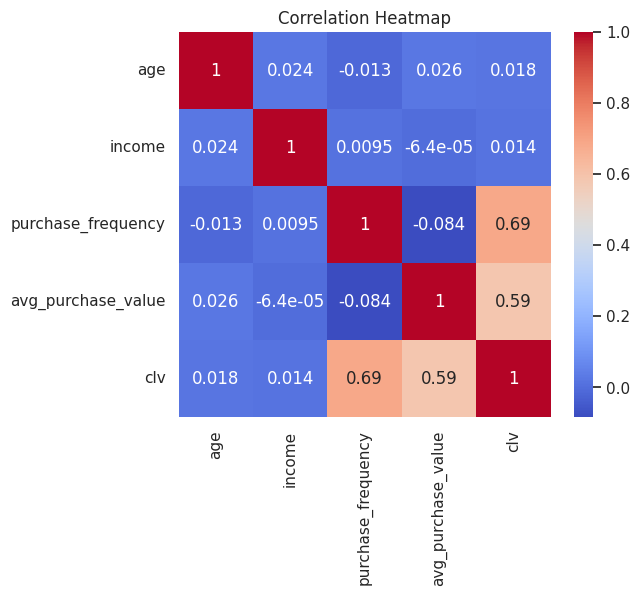

In [84]:
#   3. Correlation heatmap
plt.figure(figsize=(6, 5))

corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'clv']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Analysis
The analysis of customer behavior shows that purchase frequency and average purchase value are strong drivers of Customer Lifetime Value (CLV). Higher-income customers do not always have the highest CLV, indicating that income alone is not a strong predictor of customer value.

Customers in the 26–35 and 36–50 age groups tend to generate the highest CLV, likely due to a balance of income stability and active purchasing behavior. The top 10% of customers contribute a disproportionately large share of total CLV, highlighting the importance of customer segmentation.

# Recommendation

The company should focus marketing strategies on high-CLV customers in the 26–50 age range while designing targeted promotions to increase purchase frequency among lower-performing segments.